# Этап 2 — Признаки узлов

Для каждого ингредиента (узел графа I) строим вектор из 7 структурных признаков:

| Признак | Смысл |
|---------|-------|
| `degree` / `degree_w` | Число соседей (без веса / с весом) |
| `pagerank` | Глобальная важность в графе |
| `clustering` | Локальная кластеризация (**без веса**; weighted почти константа на co-occ) |
| `kcore` | Принадлежность к плотному ядру |
| `betweenness` | Посредничество, **приближённое** (`k=300`); длина ребра ∝ 1/log(1+weight) |
| `log_freq` | log(число рецептов) |

Признаки по графу **I** (nb01) → `node_features_structural.csv`.


In [34]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from ingredient_ru import preload_pool, ru
import ingredient_ru
import importlib
importlib.reload(ingredient_ru)
from ingredient_ru import preload_pool, ru

OUT = Path('output_graphs')
SEED = 42

# Загружаем граф и частоты из этапа 1
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')
_freq_df = pd.read_csv(OUT / 'ingredient_freq.csv')
ing_freq = dict(zip(_freq_df['ingredient'], _freq_df['freq']))
nodes = sorted(I.nodes())
preload_pool(nodes)
print(f'Загружен граф I: {I.number_of_nodes():,} узлов, {I.number_of_edges():,} рёбер')

Загружен граф I: 7,199 узлов, 418,645 рёбер


## 2.1 Вычисление признаков

`betweenness` — приближённый (k=300); в networkx `weight` = длина ребра, поэтому для сильных связей используем `length = 1/log(1+weight)`, а не сырой `weight`.

In [35]:
t0 = time.time()

pagerank    = nx.pagerank(I, weight='weight', alpha=0.85)
clustering  = nx.clustering(I)  # unweighted: weighted std≈0.0002 на co-occ графе
kcore       = nx.core_number(I)

# betweenness: weight в networkx = длина пути → инвертируем силу связи
I_bw = I.copy()
for u, v, d in I_bw.edges(data=True):
    d['length'] = 1.0 / np.log1p(d.get('weight', 1.0))
betweenness = nx.betweenness_centrality(
    I_bw, k=300, normalized=True, weight='length', seed=SEED,
)

feat_df = pd.DataFrame(index=nodes)
feat_df.index.name = 'ingredient'
feat_df['degree']      = [I.degree(n) for n in nodes]
feat_df['degree_w']    = [I.degree(n, weight='weight') for n in nodes]
feat_df['pagerank']    = feat_df.index.map(pagerank)
feat_df['clustering']  = feat_df.index.map(clustering)
feat_df['kcore']       = feat_df.index.map(kcore)
feat_df['betweenness'] = feat_df.index.map(betweenness)
feat_df['log_freq']    = feat_df.index.map(lambda n: np.log1p(ing_freq.get(n, 0)))

print(f'Готово за {time.time()-t0:.0f}с. Форма: {feat_df.shape}')
display(feat_df.describe().round(4))

Готово за 301с. Форма: (7199, 7)


,degree,degree_w,pagerank,clustering,kcore,betweenness,log_freq
count,7199.0000,7.199000e+03,7199.0000,7199.0000,7199.0000,7199.0000,7199.0000
mean,116.3064,1.996281e+04,0.0001,0.9268,63.6854,0.0001,5.5468
std,336.4176,1.751645e+05,0.0011,0.1719,78.8194,0.0081,1.5332
min,0.0000,0.000000e+00,0.0000,0.0000,0.0000,0.0000,3.9318
25%,12.0000,2.380000e+02,0.0000,0.9515,12.0000,0.0000,4.3944
50%,27.0000,6.640000e+02,0.0000,1.0000,27.0000,0.0000,5.0814
75%,80.0000,2.946000e+03,0.0000,1.0000,79.0000,0.0000,6.2236
max,6743.0000,8.238311e+06,0.0541,1.0000,276.0000,0.6663,13.7740


## 2.2 Визуализация: PCA + топ ингредиентов

PCA — на log-признаках без `degree_w`/`betweenness` (иначе соль и хабы сжимают облако в точку). Топ-3 — с фильтром NER-шума; в скобках — сырое имя узла, если перевод схлопнул вариант.

Топ по clustering — нишевые ингредиенты, чьи соседи попарно связаны; у хабов (salt, water) clustering ≈ 0, поэтому четыре строки отчёта — четыре разных вопроса к графу, а не один рейтинг.

In [36]:
# sanity-check: топ clustering среди узлов с degree≥30 (сырые имена vs ru)
sub = feat_df[feat_df['degree'] >= 30]
top = sub['clustering'].sort_values(ascending=False).head(10)
for n, v in top.items():
    print(f'{n!r:40s} clust={v:.3f}  degree={int(feat_df.loc[n, "degree"]):5d}  ru={ru(n)}')

'dry sherry'                             clust=1.000  degree=   58  ru=сухой херес
'eggs at'                                clust=1.000  degree=   31  ru=яйца
'borlotti beans'                         clust=1.000  degree=   32  ru=фасоль борлотти
'dried cranberries'                      clust=1.000  degree=   33  ru=сушёная клюква
'dried marjoram'                         clust=1.000  degree=   32  ru=сушёный майоран
'drippings'                              clust=1.000  degree=   30  ru=drippings
'boneless sirloin steak'                 clust=1.000  degree=   49  ru=без кости sirloin стейк
'boneless round steak'                   clust=1.000  degree=   41  ru=без кости стейк round
'dry wine'                               clust=1.000  degree=   34  ru=сухое вино
'sambal'                                 clust=1.000  degree=   53  ru=sambal


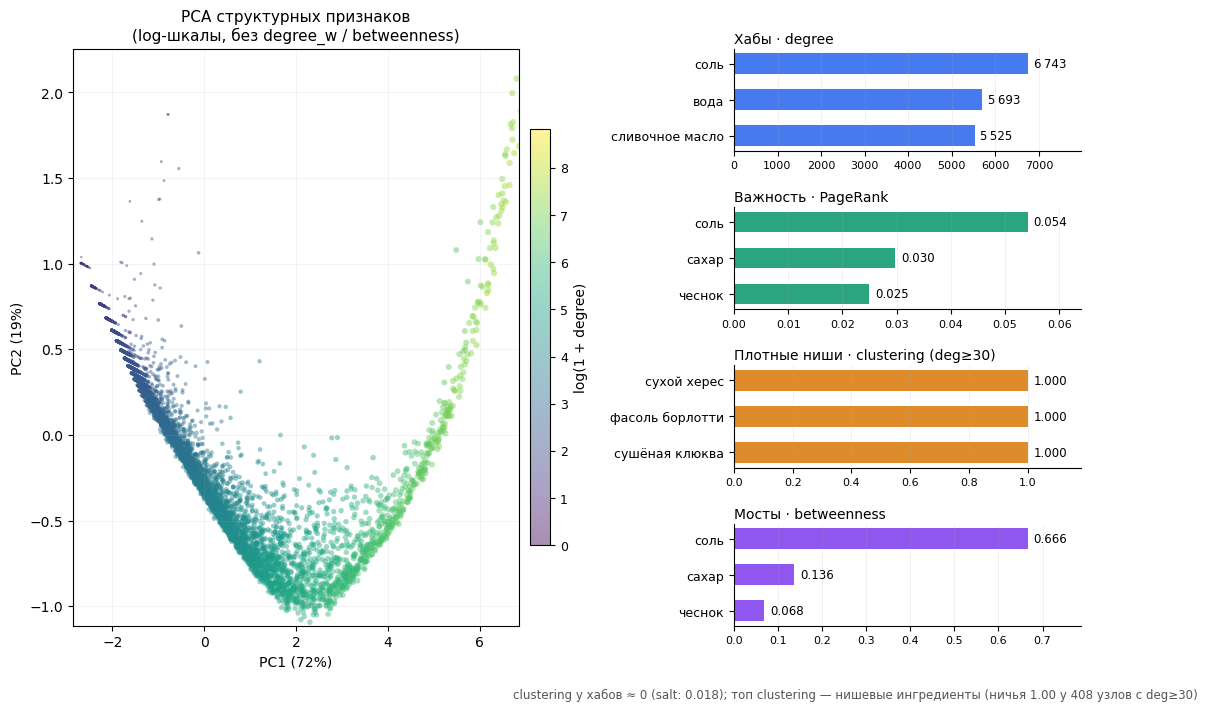

In [40]:
import re

# PCA только для визуализации: log-масштаб, без degree_w/betweenness (хвосты сжимают облако)
PCA_COLS = ['log_degree', 'pagerank', 'clustering', 'log_kcore', 'log_freq']
viz_df = pd.DataFrame({
    'log_degree': np.log1p(feat_df['degree']),
    'pagerank': feat_df['pagerank'],
    'clustering': feat_df['clustering'],
    'log_kcore': np.log1p(feat_df['kcore']),
    'log_freq': feat_df['log_freq'],
}, index=feat_df.index)
X_pca = StandardScaler().fit_transform(viz_df[PCA_COLS].values)

pca = PCA(n_components=2, random_state=SEED)
xy = pca.fit_transform(X_pca)
ev = pca.explained_variance_ratio_

_BAD_TOKENS = {'washed', 'chopped', 'sliced', 'diced', 'fresh', 'optional',
               'taste', 'frozen', 'cooked', 'ground', 'and', 'or'}
_BAD_LAST = {'at', 'of', 'in', 'on', 'with', 'to', 'for', 'a', 'an', 'the', 'into', 'until'}

def _is_real_ingredient(n: str) -> bool:
    n = n.strip()
    if len(n) < 3 or n in _BAD_TOKENS:
        return False
    if n.split()[-1] in _BAD_LAST:
        return False
    if not re.search(r'[a-zа-яё]{3,}', n):
        return False
    if n.startswith(("'s ", "s ")):
        return False
    return True

def _top3(col, min_degree=0):
    sub = feat_df if not min_degree else feat_df[feat_df['degree'] >= min_degree]
    out = []
    for n in sub[col].sort_values(ascending=False).index:
        if _is_real_ingredient(n):
            out.append((ru(n), float(sub.loc[n, col])))
        if len(out) == 3:
            break
    return out

def _fmt_val(col, v):
    if col == 'degree':
        return f'{int(v):,}'.replace(',', '\u202f')
    if col in ('pagerank', 'betweenness', 'clustering'):
        return f'{v:.3f}'
    return f'{v:.2f}'

metrics = [
    ('Хабы · degree', 'degree', 0, '#2563eb'),
    ('Важность · PageRank', 'pagerank', 0, '#059669'),
    ('Плотные ниши · clustering (deg≥30)', 'clustering', 30, '#d97706'),
    ('Мосты · betweenness', 'betweenness', 0, '#7c3aed'),
]

fig = plt.figure(figsize=(13, 7.5))
gs = fig.add_gridspec(4, 2, width_ratios=[1.55, 1], hspace=0.55, wspace=0.28)

# --- PCA слева: без подписей, размер точки = степень ---
ax_pca = fig.add_subplot(gs[:, 0])
color = np.log1p(feat_df['degree'])
sizes = np.clip(np.log1p(feat_df['degree']) * 2.8, 2, 55)
sc = ax_pca.scatter(xy[:, 0], xy[:, 1], c=color, s=sizes, cmap='viridis', alpha=0.45, linewidths=0)
cbar = fig.colorbar(sc, ax=ax_pca, label='log(1 + degree)', shrink=0.72, pad=0.02)
cbar.ax.tick_params(labelsize=9)
ax_pca.set_xlabel(f'PC1 ({ev[0]:.0%})', fontsize=10)
ax_pca.set_ylabel(f'PC2 ({ev[1]:.0%})', fontsize=10)
ax_pca.set_title('PCA структурных признаков\n(log-шкалы, без degree_w / betweenness)', fontsize=11)
ax_pca.grid(True, alpha=0.2, linewidth=0.5)

pad = 0.05
x_lo, x_hi = np.percentile(xy[:, 0], [1, 99])
y_lo, y_hi = np.percentile(xy[:, 1], [1, 99])
dx, dy = (x_hi - x_lo) * pad, (y_hi - y_lo) * pad
ax_pca.set_xlim(x_lo - dx, x_hi + dx)
ax_pca.set_ylim(y_lo - dy, y_hi + dy)

# --- топ-3 справа: горизонтальные bar chart ---
for row, (title, col, min_deg, bar_color) in enumerate(metrics):
    ax = fig.add_subplot(gs[row, 1])
    tops = _top3(col, min_deg)
    names = [t[0] for t in tops][::-1]
    vals = [t[1] for t in tops][::-1]
    bars = ax.barh(names, vals, color=bar_color, height=0.58, alpha=0.85)
    ax.set_title(title, fontsize=10, loc='left', pad=4)
    ax.set_xlim(0, max(vals) * 1.18 if vals else 1)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='x', alpha=0.25, linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_width() + max(vals) * 0.02, bar.get_y() + bar.get_height() / 2,
            _fmt_val(col, v), va='center', ha='left', fontsize=8.5,
        )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

salt_clu = feat_df.loc['salt', 'clustering']
sub30 = feat_df.loc[feat_df['degree'] >= 30, 'clustering']
n_ties = int((sub30 == 1.0).sum())
fig.text(
    0.99, 0.01,
    f'clustering у хабов ≈ 0 (salt: {salt_clu:.3f}); '
    f'топ clustering — нишевые ингредиенты (ничья 1.00 у {n_ties} узлов с deg≥30)',
    ha='right', va='bottom', fontsize=8.5, color='#555',
)

fig.savefig(OUT / 'pca_structural.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Сохранение

In [38]:
COLS = ['degree', 'degree_w', 'pagerank', 'clustering', 'kcore', 'betweenness', 'log_freq']
X_struct = StandardScaler().fit_transform(feat_df[COLS].values).astype(np.float32)

feat_df.to_csv(OUT / 'node_features_structural.csv')

np.savez_compressed(
    OUT / 'node_features.npz',
    nodes     = np.array(nodes, dtype=object),
    X_struct  = X_struct,
    feat_cols = np.array(COLS, dtype=object),
)

print('Сохранено: node_features_structural.csv, node_features.npz')
print(f'Матрица признаков: {X_struct.shape}')

Сохранено: node_features_structural.csv, node_features.npz
Матрица признаков: (7199, 7)
